# Retrieve customer.io user data

In [2]:
from Customerio_Event_Data_utils import retrieve_event_summary
import pandas as pd

summary_df = retrieve_event_summary()
summary_df.head()

event_name,app_login,clicked,email_opened
date,,,
2024-10-26,80,84,83
2024-10-27,74,93,82
2024-10-28,68,88,91
2024-10-29,79,88,85
2024-10-30,85,76,79


# Aggregate Weekly Counts

In [3]:
summary_df.index = pd.to_datetime(summary_df.index)  # ensure index is datetime

weekly_summary = summary_df.resample("W").sum()
weekly_summary.head()

event_name,app_login,clicked,email_opened
date,,,
2024-10-27,154,177,165
2024-11-03,531,576,582
2024-11-10,631,582,616
2024-11-17,638,634,570
2024-11-24,585,606,592


# Visualize Daily Trends

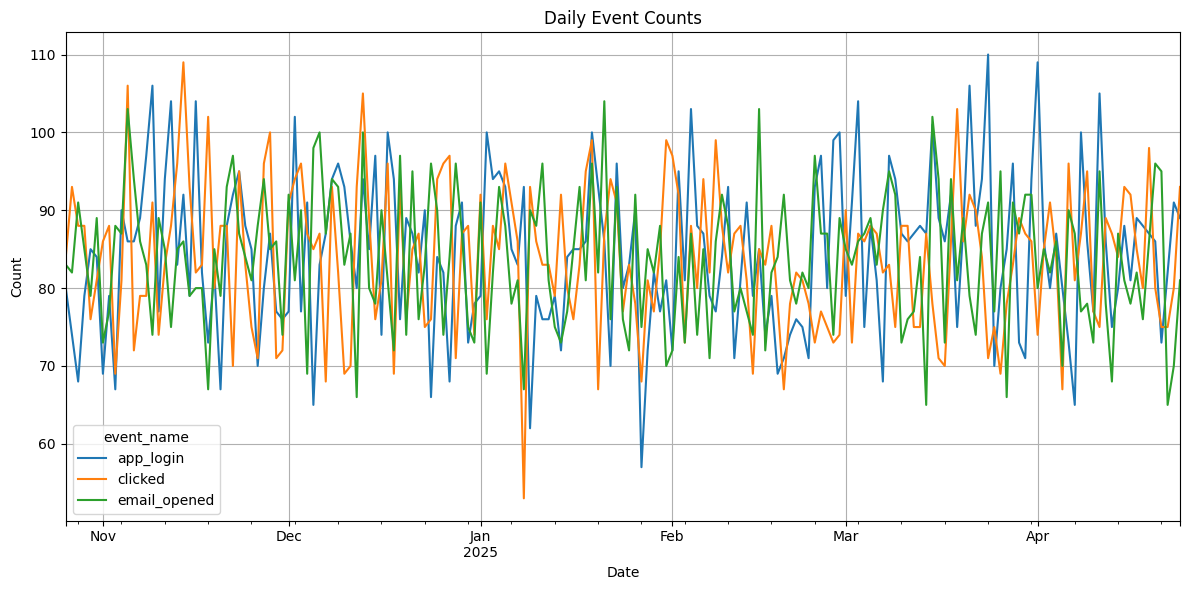

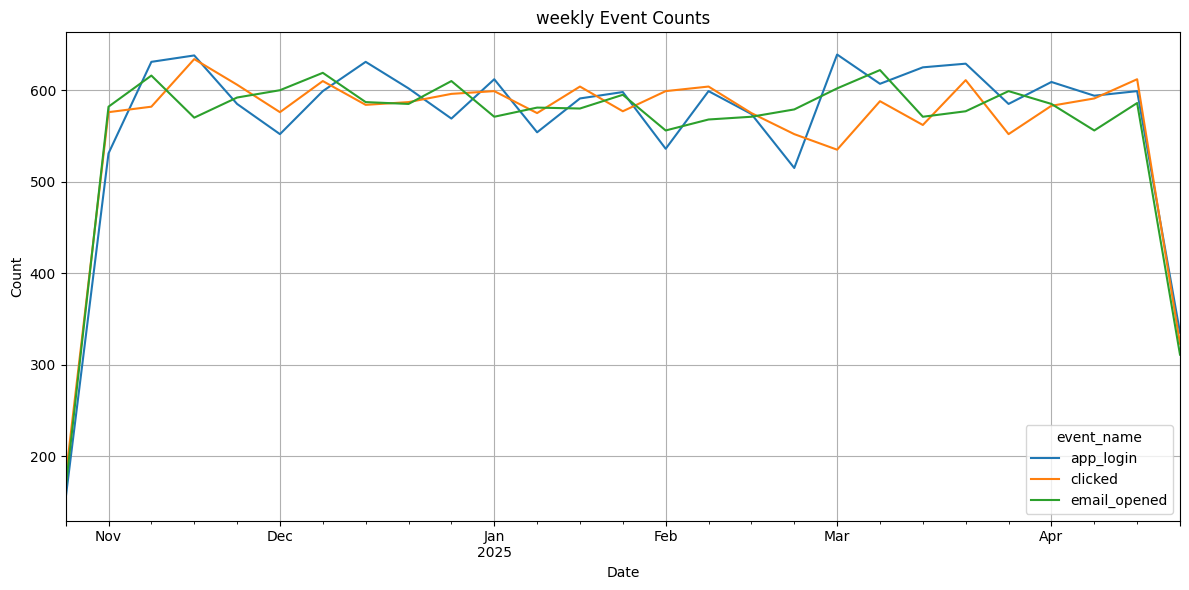

In [4]:
import matplotlib.pyplot as plt

summary_df.plot(figsize=(12, 6), title="Daily Event Counts")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

weekly_summary.plot(figsize=(12, 6), title="weekly Event Counts")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Detect Campaign Spikes (Basic Trend Insight)

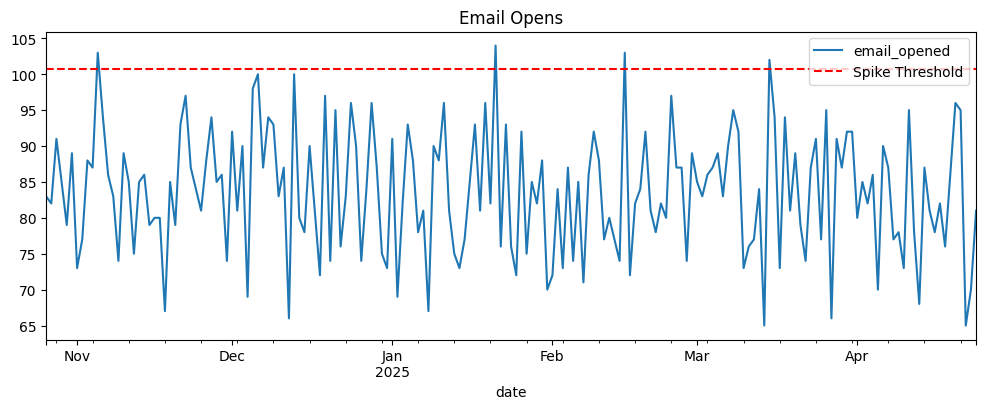

Spike Dates:
2024-11-05
2025-01-21
2025-02-15
2025-03-15


In [31]:
summary_df["email_opened"].plot(figsize=(12, 4), title="Email Opens")
plt.axhline(summary_df["email_opened"].mean() + 2 * summary_df["email_opened"].std(), color='red', linestyle='--', label='Spike Threshold')
plt.legend()
plt.show()

# Calculate spike threshold
threshold = summary_df["email_opened"].mean() + 2 * summary_df["email_opened"].std()

# Find dates where value exceeds threshold
spike_dates = summary_df[summary_df["email_opened"] > threshold].index

# Print spike dates
print("Spike Dates:")
for date in spike_dates:
    print(date.strftime("%Y-%m-%d"))

#  Forecasting with ARIMA


=== Forecasting: email_opened ===
MAE: 8.11
RMSE: 9.72


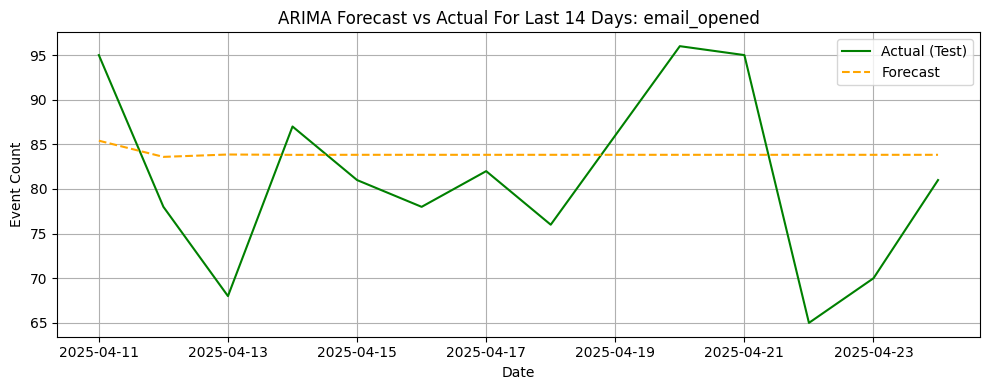


=== Forecasting: app_login ===
MAE: 5.80
RMSE: 7.72


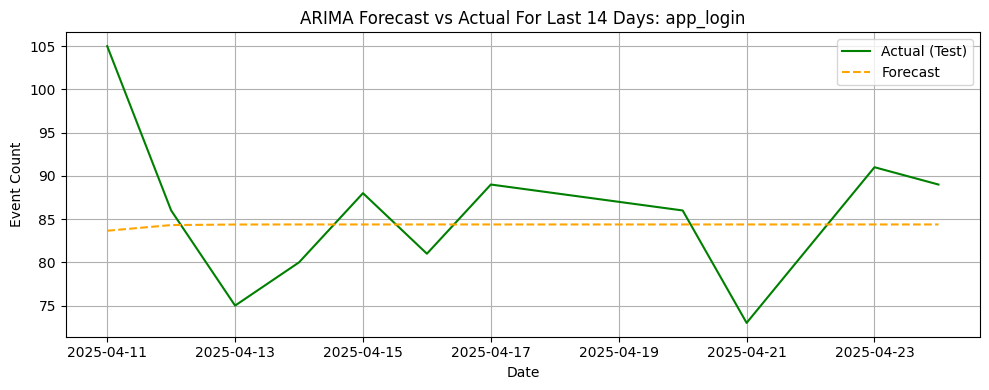


=== Forecasting: clicked ===
MAE: 6.39
RMSE: 7.43


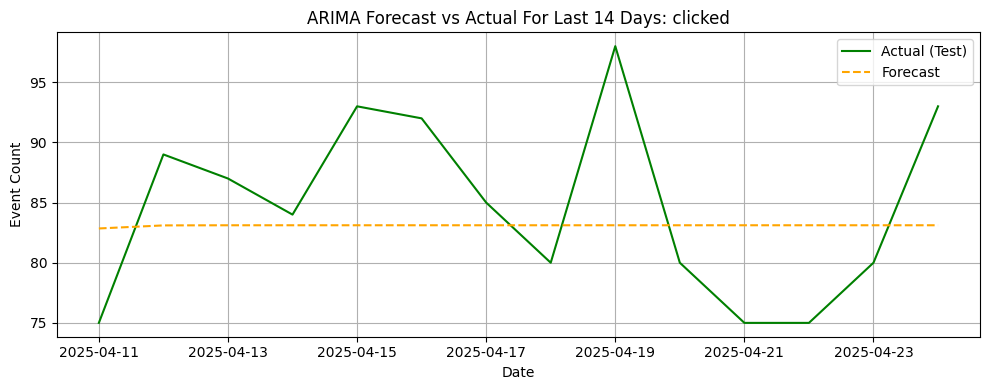

In [29]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# List of event types to forecast
event_types = ["email_opened", "app_login", "clicked"]

for event in event_types:
    print(f"\n=== Forecasting: {event} ===")

    # Prepare series
    series = summary_df[event]
    series.index = pd.to_datetime(series.index)
    series = series.asfreq("D").fillna(0)

    # Split train/test
    train = series[:-14]
    test = series[-14:]

    # Fit ARIMA(1,1,1)
    model = ARIMA(train, order=(1, 1, 1))
    model_fit = model.fit(start_params=[0.1]*model.k_params, method_kwargs={'warn_convergence': False})

    # Forecast
    forecast = model_fit.forecast(steps=14)
    forecast.index = test.index

    # Evaluate
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    # Plot test period only
    plt.figure(figsize=(10, 4))
    plt.plot(test.index, test, label="Actual (Test)", color="green")
    plt.plot(forecast.index, forecast, label="Forecast", color="orange", linestyle="--")
    plt.title(f"ARIMA Forecast vs Actual For Last 14 Days: {event}")
    plt.xlabel("Date")
    plt.ylabel("Event Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Anomaly Detection (Simple Z-score or Threshold)

In [10]:
from scipy.stats import zscore

summary_df["zscore_email"] = zscore(summary_df["email_opened"])
anomalies = summary_df[summary_df["zscore_email"].abs() > 2]

print("📉 Anomalies Detected:")
print(anomalies[["email_opened", "zscore_email"]])

📉 Anomalies Detected:
event_name  email_opened  zscore_email
date                                  
2024-11-05           103      2.263521
2024-12-12            66     -2.058920
2025-01-21           104      2.380344
2025-02-15           103      2.263521
2025-03-14            65     -2.175743
2025-03-15           102      2.146698
2025-03-27            66     -2.058920
2025-04-22            65     -2.175743
